# Global Coffee Analysis

### Global Coffee Production

Green Coffee Beans Production 2000-2023

Source: https://ourworldindata.org/grapher/coffee-production-by-region#sources-and-processing

In [190]:
import pandas as pd
import plotly.express as px
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.graph_objects as go



# Fetch the data
coffee_production_df = pd.read_csv('coffee-bean-production(2000-23).csv')

# Seperate data into two Dataframe: individual countires and regions
individual_countries = coffee_production_df[coffee_production_df["Code"].notna() & ~coffee_production_df["Code"].str.startswith("OWID_", na=False)].reset_index(drop=True)
regions = coffee_production_df[coffee_production_df["Code"].isna() | coffee_production_df["Code"].str.startswith("OWID_", na=False)].reset_index(drop=True)

# World Totals Grouped by Year
world_totals = regions[regions["Code"] == "OWID_WRL"]
world_totals_by_year = world_totals.groupby("Year")["Total_GreenBeans_Tonnes"].sum().reset_index()

# Group Individual Country df By Year, adding Total column (Should be the same as the World Total by year (discrep < .5))
# individual_countries_group_year = individual_countries.groupby('Year')['Total_GreenBeans_Tonnes'].sum().reset_index()

# TO DO: Graph world_totals_by_year
# YOY production of coffee beans


# Order by individual countries (largest producers) Aggregate Add column to show % of total production
# so for each year will have a list of x amount sorted based on total production
# 
# Or just do it for the Most Recent Year or Do it avg from all data, or average last 5 years of data

total_tonnes_produced_23_years = world_totals_by_year["Total_GreenBeans_Tonnes"].sum()
# Average of All Years
# SELECT Entity, SUM(Total_GreenBeans_Tonnes) AS Total_Tonnes_23_Years, (Total_Tonnes_23_Years/total_tonnes_produced_23_years) GROUP BY Code (or Entity)

total_averages_by_countries_23_years = (
    individual_countries.groupby(["Code", "Entity"])
    ["Total_GreenBeans_Tonnes"]
    .sum()
    .reset_index()
)

# Add the percentage column
total_averages_by_countries_23_years["Share %"] = (
    total_averages_by_countries_23_years["Total_GreenBeans_Tonnes"] / 
    total_tonnes_produced_23_years * 100
).round(3)

# SORT
total_averages_by_countries_23_years = total_averages_by_countries_23_years.sort_values(
    "Total_GreenBeans_Tonnes", 
    ascending=False
).reset_index()


example = total_averages_by_countries_23_years.head(15)
example['sum15']= (example["Share %"].sum())

print(example.head(15))
# # Top 10 Scatter Geo Map
# top_10 = total_averages_by_countries_23_years.nlargest(10, 'Share %')
# top_10_scatter_map = px.scatter_geo(
#         top_10,
#         locations="Code",
#         locationmode="ISO-3",
#         size="Total_GreenBeans_Tonnes", 
#         hover_data= {
#             "Entity": True, 
#             "Share %": True,
#             "Code": False       
#         },
#         projection="equirectangular",
#     )
# top_10_scatter_map.update_traces(
#     marker=dict(
#         size=total_averages_by_countries_23_years["Total_GreenBeans_Tonnes"] * 5,
#         color="#50321D",  # Brown color
#     ),
#     hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]}%<extra></extra>"
# )

# # Update geos
# top_10_scatter_map.update_geos(
#     showcoastlines=True,
#     coastlinecolor="Black",
#     showland=True,
#     landcolor="White",
#     showcountries=True,
#     countrycolor="Black",
#     countrywidth=1,
#     showocean=True,
#     oceancolor="#8BB8DD",
#     showlakes=True,
#     lakecolor="#8BB8DD",
# )

# # Update layout
# top_10_scatter_map.update_layout(
#     title={
#         'text': "Global Coffee Production 2000-2023 - Top Producers",
#         'x': 0.5,
#         'xanchor': 'center',
#         'font': {'size': 34, 'family': 'Sans Serif'},
#     },
#     font= {'family': 'Sans Serif'}
# )

# top_10_scatter_map.show(renderer="browser")





# Order by region Aggregate
# Largest Producers last 5 years Countries + Region
# Display in Table, Map Thinking Circle over region, size of circle based on total %


    index Code         Entity  Total_GreenBeans_Tonnes  Share %   sum15
0       5  BRA         Brazil              65596612.00   30.831  87.617
1      74  VNM        Vietnam              30885127.60   14.516  87.617
2      13  COL       Colombia              16448246.64    7.731  87.617
3      32  IDN      Indonesia              16418892.70    7.717  87.617
4      21  ETH       Ethiopia               8407947.52    3.952  87.617
5      33  IND          India               7257629.77    3.411  87.617
6      30  HND       Honduras               7104594.68    3.339  87.617
7      52  PER           Peru               6679792.82    3.140  87.617
8      28  GTM      Guatemala               5891002.04    2.769  87.617
9      41  MEX         Mexico               5671602.91    2.666  87.617
10     70  UGA         Uganda               5601771.00    2.633  87.617
11      8  CIV  Cote d'Ivoire               3333480.26    1.567  87.617
12     16  CRI     Costa Rica               2506532.00    1.178 

/var/folders/fp/qc5b6ltj5k5f79xpmxlb5cf00000gn/T/ipykernel_14700/4207968748.py:57: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [2]:
import pandas as pd
consumption_data = pd.read_csv("Coffee Consumption(Sheet1).csv")

consumption_country_totals = (
    consumption_data.groupby("Country")["Thousand Units (Bags of 60 kg)"]
    .sum()
    .reset_index()
    .rename(columns={"Thousand Units (Bags of 60 kg)": "Total_Coffee"})
    .sort_values(by="Total_Coffee", ascending=False)
)
print(consumption_country_totals)

               Country  Total_Coffee
17                 USA     629835.80
0               Brazil     464439.00
8                Japan     203470.40
12             Russia       84948.84
7            Indonesia      82159.00
3             Ethiopia      77220.00
9               Mexico      53213.00
11         Philippines      46955.00
1             Colombia      42085.97
18           Venezuela      40070.56
6                India      34935.88
19             Vietnam      32246.12
13         Switzerland      28664.90
10              Norway      21942.23
14            Thailand      20866.00
16              Turkey      15948.71
2   Dominican Republic      10729.06
4            Guatemala       9856.00
15             Tunisia       8191.28
5             Honduras       7898.58


In [3]:
import_data = pd.read_csv("coffee(unroasted green beans) import export(import).csv")
grouped_import_data = import_data.groupby("Country")["Value (t)"].sum().sort_values(ascending=False)
top_importers = grouped_import_data.head(10).reset_index()
print(top_importers)

                        Country    Value (t)
0      United States of America  13284784.92
1                       Germany   9946892.75
2                         Italy   5412921.24
3                         Japan   3653816.62
4                       Belgium   2774643.35
5                         Spain   2714225.48
6                        France   1997491.67
7  Netherlands (Kingdom of the)   1766352.92
8                        Canada   1749995.65
9                   Switzerland   1599338.32


In [3]:
import ssl
print(ssl.get_default_verify_paths())

DefaultVerifyPaths(cafile=None, capath=None, openssl_cafile_env='SSL_CERT_FILE', openssl_cafile='/Library/Frameworks/Python.framework/Versions/3.13/etc/openssl/cert.pem', openssl_capath_env='SSL_CERT_DIR', openssl_capath='/Library/Frameworks/Python.framework/Versions/3.13/etc/openssl/certs')


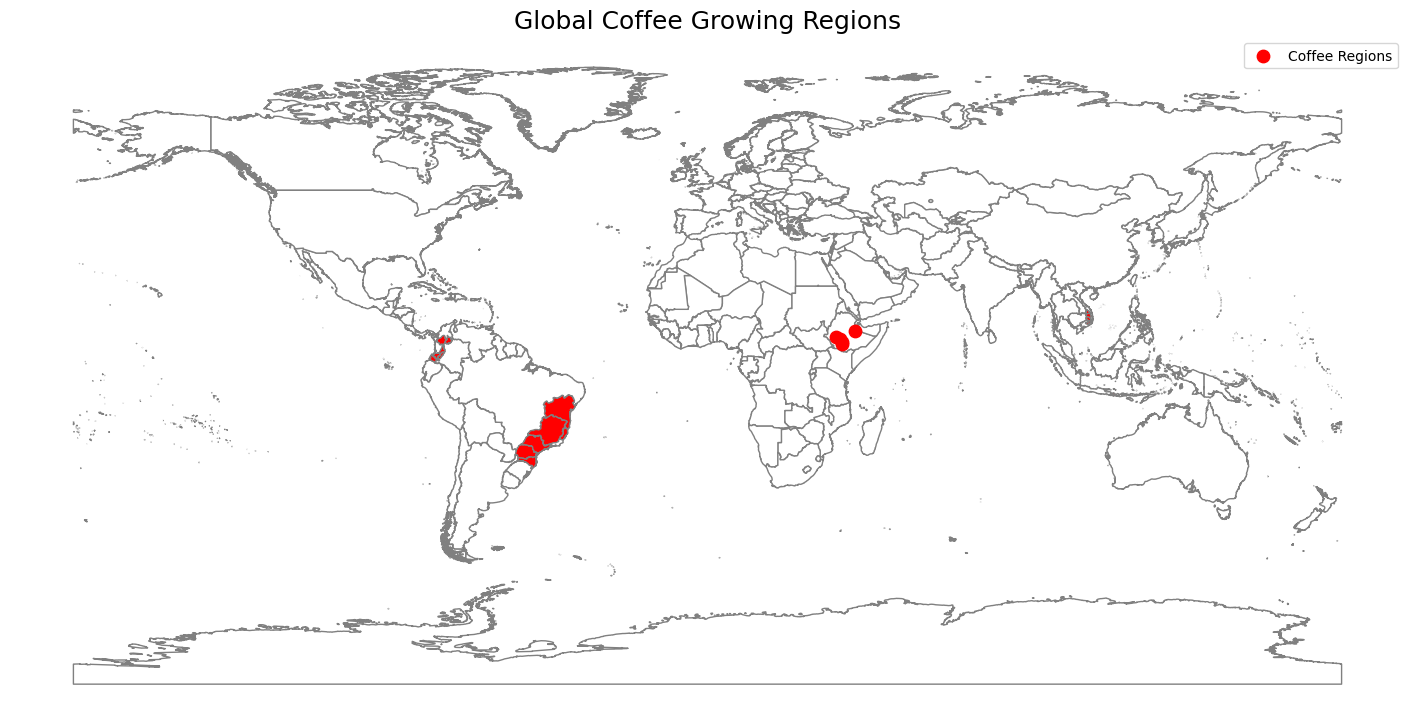

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pandas as pd

# -----------------------
# Load Natural Earth admin-1 shapefile
# -----------------------
admin1 = gpd.read_file("ne_10m_admin_1_states_provinces.zip")

# -----------------------
# Select coffee regions per country
# -----------------------

# Brazil
brazil = admin1[admin1["admin"] == "Brazil"]
brazil_coffee = brazil[brazil["name"].isin([
    "Minas Gerais", "São Paulo", "Paraná",
    "Espírito Santo", "Bahia", "Santa Catarina"
])]

# Vietnam
vietnam = admin1[admin1["admin"] == "Vietnam"]
vietnam_coffee = vietnam[vietnam["name"].isin([
    "Đắk Lắk", "Lâm Đồng", "Gia Lai", "Kon Tum"
])]

# Colombia
colombia = admin1[admin1["admin"] == "Colombia"]
colombia_coffee = colombia[colombia["name"].isin([
    "Antioquia", "Huila", "Tolima", "Nariño", "Cauca", "Santander"
])]

# Indonesia
indonesia = admin1[admin1["admin"] == "Indonesia"]
indonesia_coffee = indonesia[indonesia["name"].isin([
    "Sumatra", "Java", "Sulawesi", "Bali", "Flores"
])]

# Combine all shaded coffee regions using pd.concat
coffee_regions = pd.concat([
    brazil_coffee,
    vietnam_coffee,
    colombia_coffee,
    indonesia_coffee
], ignore_index=True)

# -----------------------
# Ethiopia coffee points
# -----------------------
ethiopia_points = gpd.GeoDataFrame(
    {
        "region": ["Sidamo", "Yirgacheffe", "Limu", "Harrar", "Jimma/Kaffa"],
        "geometry": [
            Point(38.2, 5.7),
            Point(38.1, 6.2),
            Point(37.6, 7.0),
            Point(42.0, 9.3),
            Point(36.5, 7.7)
        ]
    },
    crs="EPSG:4326"
)

# -----------------------
# Plot global map
# -----------------------
world = admin1.dissolve(by="admin").reset_index()  # Combine states into country polygons

fig, ax = plt.subplots(figsize=(18,10))

# World base map
world.plot(ax=ax, color='white', edgecolor='gray')

# Coffee regions
coffee_regions.plot(ax=ax, color='red', edgecolor='gray')

# Ethiopia points
ethiopia_points.plot(ax=ax, color='red', markersize=80, label='Ethiopia Coffee')

# Optional: add legend
ax.legend(["Coffee Regions"])

# Title and styling
ax.set_title("Global Coffee Growing Regions", fontsize=18)
ax.set_axis_off()

plt.show()


In [ ]:

with tab1:
    st.header("Climate Risk")
    st.markdown("From 2025 to 2100, the planet is projected to rise about x")

# Climate Risk

# use existing index on country climate risk
# 
# use climate data to layer over data about where coffee is produced (the actual land)
# the risk comes with higher temps and drought or floods. 



# bring up commodity pricing and futures (world bank API)
# how the climate and financial projection will clash or align?